In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Chargement de la base de données 
df = pd.read_csv("C:/Users/Crédit/default.csv")
print(f'Dimensions : {df.shape}')
df.head()






Dimensions : (1000, 12)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,lcredit,Age2,default
0,67,male,2,own,NaN,little,1169,6,radio/TV,7.063904,4489,1
1,22,female,2,own,little,moderate,5951,48,radio/TV,8.691315,484,2
2,49,male,1,own,little,NaN,2096,12,education,7.647786,2401,1
3,45,male,2,free,little,little,7882,42,furniture/equipment,8.972337,2025,1
4,53,male,2,free,little,little,4870,24,car,8.490849,2809,2


In [20]:
# Recodage de la variable default


# Recodage : 1 -> 0 (Good), 2 -> 1 (Bad/Défaut)
df['default'] = df['default'].map({1: 0, 2: 1})

print('Distribution de la variable cible après recodage :')
print(df['default'].value_counts())
print(f"\nTaux de défaut : {df['default'].mean()*100:.1f}%")



Distribution de la variable cible après recodage :
default
0    700
1    300
Name: count, dtype: int64

Taux de défaut : 30.0%


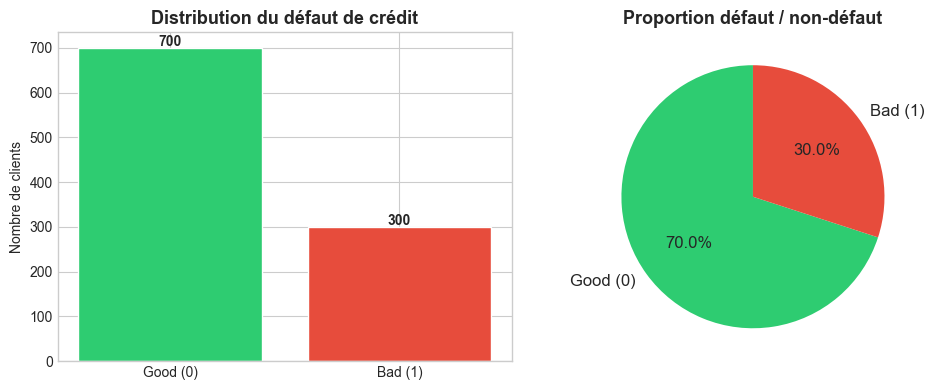

In [21]:


# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Barplot
counts = df['default'].value_counts()
axes[0].bar(['Good (0)', 'Bad (1)'], counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0].set_title('Distribution du défaut de crédit', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Camembert
axes[1].pie(counts.values, labels=['Good (0)', 'Bad (1)'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proportion défaut / non-défaut', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('Graphiques/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



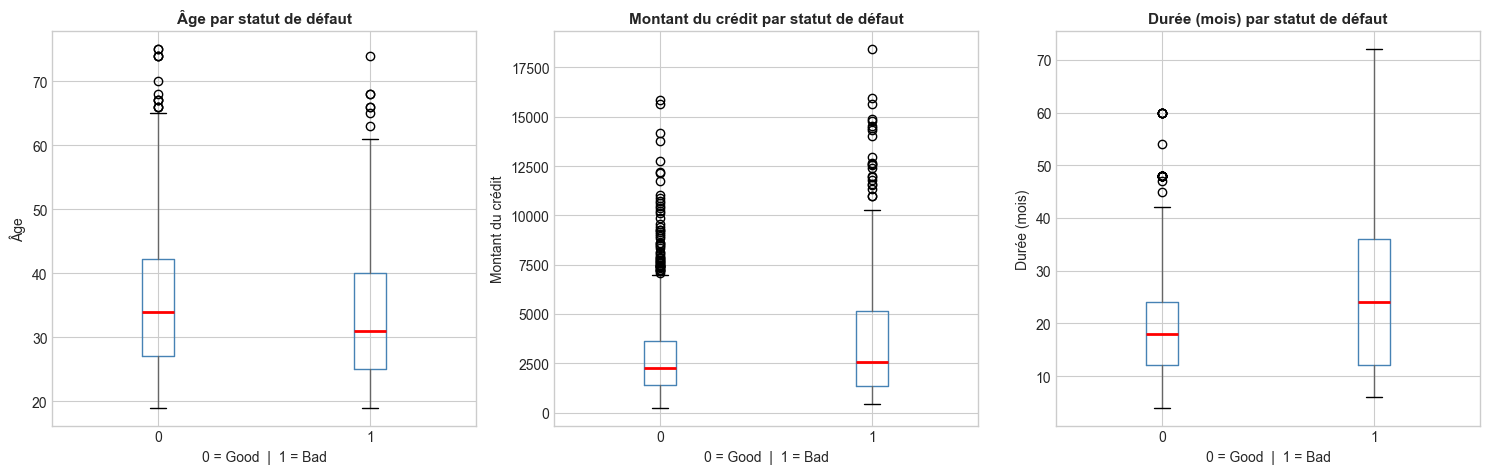

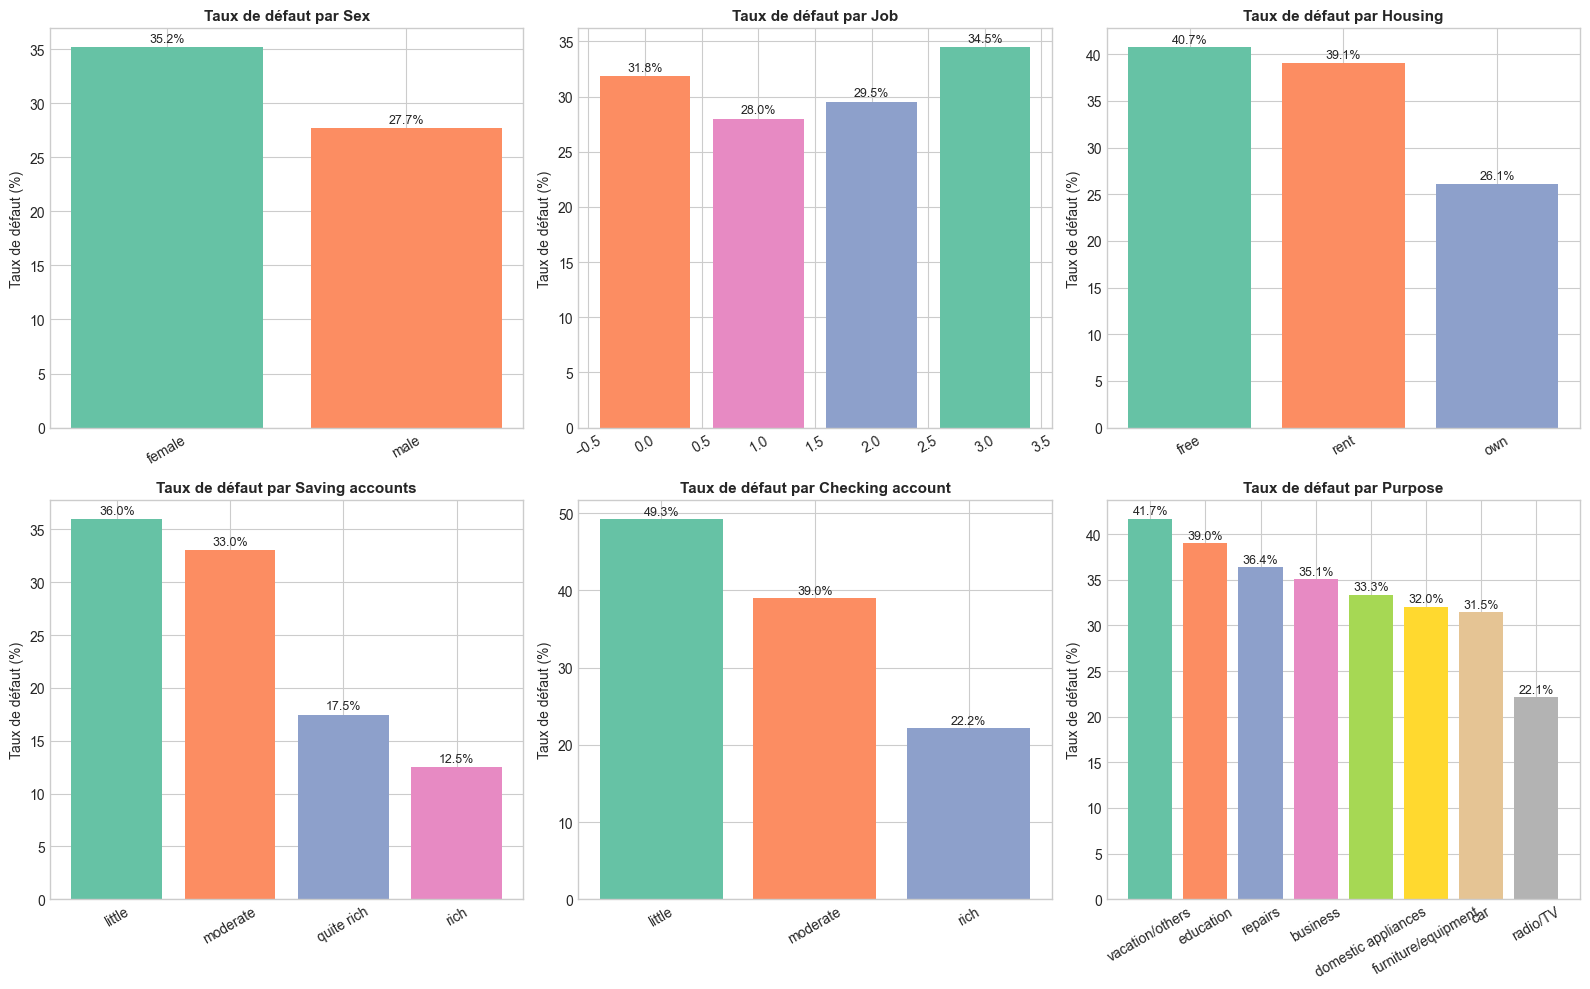

In [23]:
# ANALYSE EXPLORATOIRE DES DONNEES

# Résumé statistique
df.describe().round(2)



# Défaut selon les variables numériques clés
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, var, title in zip(axes,
                           ['Age', 'Credit amount', 'Duration'],
                           ['Âge', 'Montant du crédit', 'Durée (mois)']):
    df.boxplot(column=var, by='default', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{title} par statut de défaut', fontsize=11, fontweight='bold')
    ax.set_xlabel('0 = Good  |  1 = Bad')
    ax.set_ylabel(title)

plt.suptitle('')
plt.tight_layout()
plt.savefig('Graphiques/boxplots_default.png', dpi=150, bbox_inches='tight')
plt.show()




# Taux de défaut par variable catégorielle
cat_vars = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, var in zip(axes, cat_vars):
    taux = df.groupby(var)['default'].mean().sort_values(ascending=False) * 100
    bars = ax.bar(taux.index, taux.values, color=sns.color_palette('Set2', len(taux)))
    ax.set_title(f'Taux de défaut par {var}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Taux de défaut (%)')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, taux.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('Graphiques/default_rate_by_category.png', dpi=150, bbox_inches='tight')
plt.show()




In [24]:

#ENCODAGE DES VARIABLES CATEGORIELLES 


df_model = df.copy()

le = LabelEncoder()
cat_vars = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

for col in cat_vars:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print('Types après encodage :')
print(df_model.dtypes)
df_model.head()






Types après encodage :
Age                   int64
Sex                   int64
Job                   int64
Housing               int64
Saving accounts       int64
Checking account      int64
Credit amount         int64
Duration              int64
Purpose               int64
lcredit             float64
Age2                  int64
default               int64
dtype: object


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,lcredit,Age2,default
0,67,1,2,1,4,0,1169,6,5,7.063904,4489,0
1,22,0,2,1,0,1,5951,48,5,8.691315,484,1
2,49,1,1,1,0,3,2096,12,3,7.647786,2401,0
3,45,1,2,0,0,0,7882,42,4,8.972337,2025,0
4,53,1,2,0,0,0,4870,24,1,8.490849,2809,1


In [25]:
# SELECTION DES VARIABLES ET SEPARATION TRAIN / TEST : 

# Variables explicatives (on inclut les variables transformées lcredit et Age2)
features = ['Age', 'Age2', 'Sex', 'Job', 'Housing',
            'Saving accounts', 'Checking account',
            'lcredit', 'Duration', 'Purpose']

X = df_model[features]
y = df_model['default']

# Séparation 80% train / 20% test avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]} observations ({y_train.mean()*100:.1f}% défaut)')
print(f'Test  : {X_test.shape[0]} observations ({y_test.mean()*100:.1f}% défaut)')






Train : 800 observations (30.0% défaut)
Test  : 200 observations (30.0% défaut)


In [26]:
#MODELE 1 : REGRESSION LOGIT

logit = LogisticRegression(max_iter=1000, random_state=42)
logit.fit(X_train, y_train)

y_pred_logit = logit.predict(X_test)
y_prob_logit = logit.predict_proba(X_test)[:, 1]

print('=== Régression Logistique ===')
print(classification_report(y_test, y_pred_logit,
                             target_names=['Good (0)', 'Bad (1)']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_logit):.4f}')





=== Régression Logistique ===
              precision    recall  f1-score   support

    Good (0)       0.78      0.86      0.82       140
     Bad (1)       0.58      0.43      0.50        60

    accuracy                           0.73       200
   macro avg       0.68      0.65      0.66       200
weighted avg       0.72      0.73      0.72       200

ROC-AUC : 0.7786


In [27]:

# Coefficients du modèle Logit
coef_df = pd.DataFrame({
    'Variable': features,
    'Coefficient': logit.coef_[0],
    'Odds Ratio': np.exp(logit.coef_[0])
}).sort_values('Coefficient', ascending=False)

print('\nCoefficients et Odds Ratios :')
print(coef_df.to_string(index=False))





Coefficients et Odds Ratios :
        Variable  Coefficient  Odds Ratio
         Housing     0.216125    1.241258
        Duration     0.044128    1.045116
             Job     0.036720    1.037402
            Age2     0.000389    1.000390
             Age    -0.034015    0.966557
         Purpose    -0.055217    0.946280
         lcredit    -0.074705    0.928017
 Saving accounts    -0.241692    0.785298
             Sex    -0.358589    0.698661
Checking account    -0.568529    0.566358


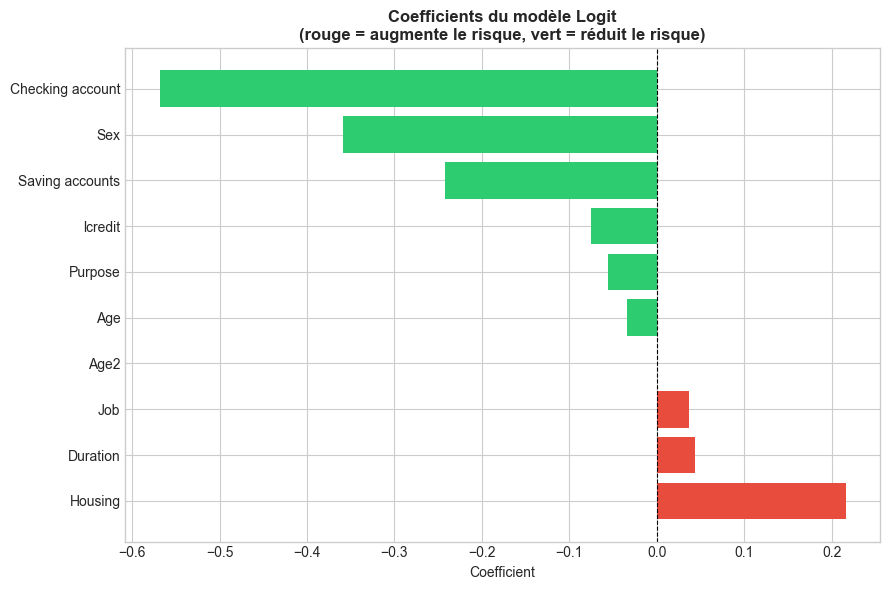

In [28]:
# Graphique des coefficients
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['Coefficient']]
ax.barh(coef_df['Variable'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Coefficients du modèle Logit\n(rouge = augmente le risque, vert = réduit le risque)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.savefig('Graphiques/logit_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()





In [29]:
#MODELE 2 : RANDOM FOREST

rf = RandomForestClassifier(n_estimators=200, max_depth=6,
                             class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf,
                             target_names=['Good (0)', 'Bad (1)']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_rf):.4f}')





=== Random Forest ===
              precision    recall  f1-score   support

    Good (0)       0.84      0.74      0.79       140
     Bad (1)       0.53      0.67      0.59        60

    accuracy                           0.72       200
   macro avg       0.68      0.70      0.69       200
weighted avg       0.74      0.72      0.73       200

ROC-AUC : 0.7989


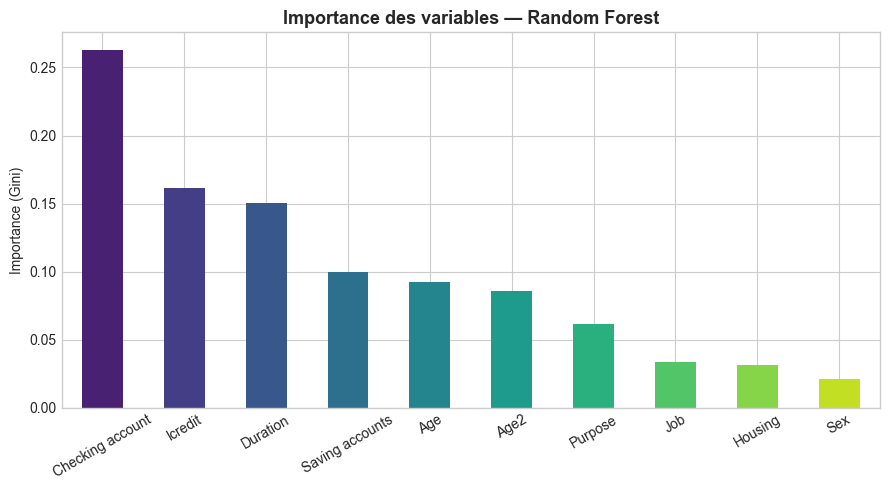

In [30]:
# Importance des variables — Random Forest
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
importances.plot(kind='bar', ax=ax, color=sns.color_palette('viridis', len(importances)))
ax.set_title('Importance des variables — Random Forest', fontsize=13, fontweight='bold')
ax.set_ylabel('Importance (Gini)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('Graphiques/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()




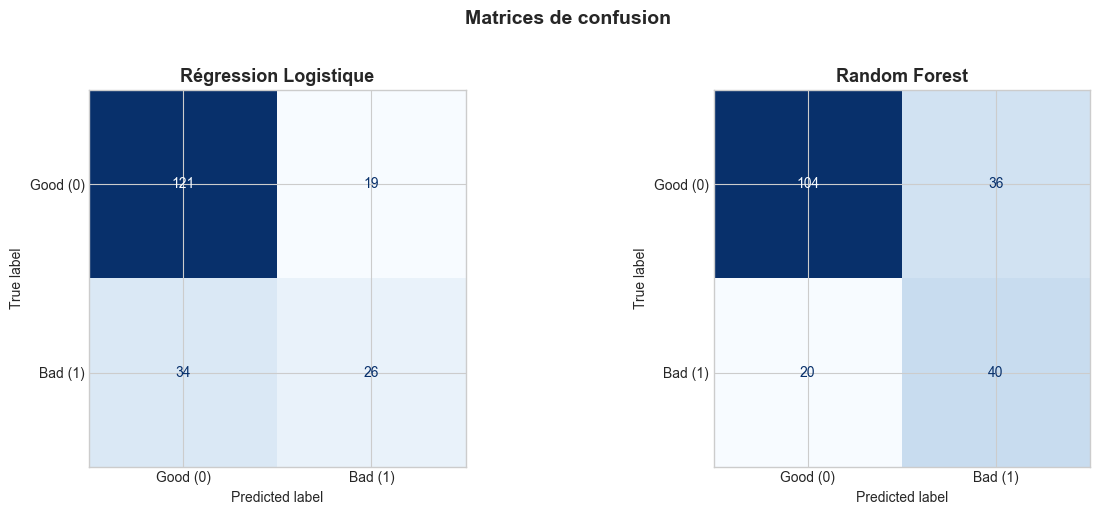


⚠️  Rappel économique :
Prédire Good (0) alors que le client est Bad (1) = FAUX NÉGATIF = perte financière pour la banque
→ On surveille particulièrement le Recall de la classe Bad (1)


In [31]:
# EVALUATION ET COMPARAISON DES MODELES


# Matrices de confusion côte à côte
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, titre in zip(axes,
                              [y_pred_logit, y_pred_rf],
                              ['Régression Logistique', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Good (0)', 'Bad (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titre, fontsize=13, fontweight='bold')

plt.suptitle('Matrices de confusion', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Graphiques/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n⚠️  Rappel économique :')
print('Prédire Good (0) alors que le client est Bad (1) = FAUX NÉGATIF = perte financière pour la banque')
print('→ On surveille particulièrement le Recall de la classe Bad (1)')






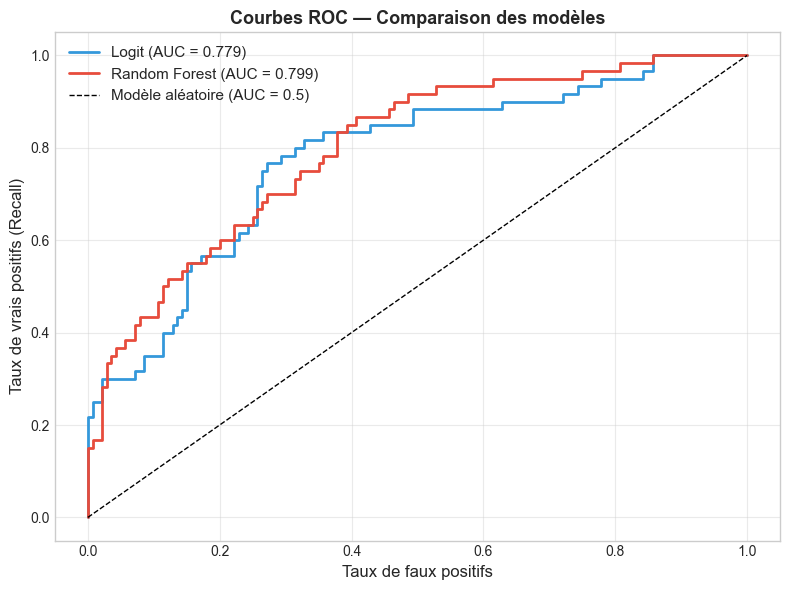

In [32]:

# Courbes ROC comparatives
fig, ax = plt.subplots(figsize=(8, 6))

for y_prob, label, color in [
    (y_prob_logit, 'Logit', '#3498db'),
    (y_prob_rf,    'Random Forest', '#e74c3c')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{label} (AUC = {auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Modèle aléatoire (AUC = 0.5)')
ax.set_xlabel('Taux de faux positifs', fontsize=12)
ax.set_ylabel('Taux de vrais positifs (Recall)', fontsize=12)
ax.set_title('Courbes ROC — Comparaison des modèles', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('Graphiques/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()




In [33]:

# Tableau récapitulatif
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

results = pd.DataFrame({
    'Modèle': ['Logit', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_logit),
        accuracy_score(y_test, y_pred_rf)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_logit),
        roc_auc_score(y_test, y_prob_rf)
    ],
    'Recall (Bad)': [
        recall_score(y_test, y_pred_logit),
        recall_score(y_test, y_pred_rf)
    ],
    'Precision (Bad)': [
        precision_score(y_test, y_pred_logit),
        precision_score(y_test, y_pred_rf)
    ],
    'F1-Score (Bad)': [
        f1_score(y_test, y_pred_logit),
        f1_score(y_test, y_pred_rf)
    ]
}).round(4)

print('=== Tableau comparatif des modèles ===')
results




=== Tableau comparatif des modèles ===


,Modèle,Accuracy,ROC-AUC,Recall (Bad),Precision (Bad),F1-Score (Bad)
0,Logit,0.735,0.7786,0.4333,0.5778,0.4952
1,Random Forest,0.720,0.7989,0.6667,0.5263,0.5882


In [34]:

# SCORING CREDIT MODEL 



# Score de risque individuel (probabilité de défaut)
df_test_results = X_test.copy()
df_test_results['default_réel'] = y_test.values
df_test_results['proba_défaut_logit'] = y_prob_logit
df_test_results['proba_défaut_rf']    = y_prob_rf
df_test_results['score_risque'] = df_test_results['proba_défaut_rf'].apply(
    lambda p: 'Risque élevé' if p > 0.6 else ('Risque modéré' if p > 0.35 else 'Risque faible')
)

print('Distribution des scores de risque (Random Forest) :')
print(df_test_results['score_risque'].value_counts())

print('\n10 clients avec le risque de défaut le plus élevé :')
df_test_results.nlargest(10, 'proba_défaut_rf')[['proba_défaut_rf', 'default_réel', 'score_risque']]



Distribution des scores de risque (Random Forest) :
score_risque
Risque faible    94
Risque modéré    53
Risque élevé     53
Name: count, dtype: int64

10 clients avec le risque de défaut le plus élevé :


,proba_défaut_rf,default_réel,score_risque
887,0.812793,1,Risque élevé
832,0.806144,1,Risque élevé
11,0.801939,1,Risque élevé
522,0.794908,1,Risque élevé
831,0.785706,1,Risque élevé
570,0.768053,1,Risque élevé
915,0.750317,1,Risque élevé
375,0.745458,1,Risque élevé
840,0.740713,1,Risque élevé
43,0.739568,0,Risque élevé
